# 교호작용 EDA: 100원딜 × 다른 변수 → 재구매 / 이탈방지

`is_100` (100원 프로모션 여부) 와 다른 변수들의 **교호작용(interaction)** 이  
`is_repurchase`, `is_churn_prevented` 에 미치는 영향을 분석합니다.

| 분석 | 설명 |
|------|------|
| is_100 × gender | 성별에 따라 100원딜 효과가 다른가? |
| is_100 × age_group | 연령대별 100원딜 효과 차이 |
| is_100 × payment_device | 결제 기기별 100원딜 효과 |
| is_100 × max_screen | 동시접속 화면 수 × 100원딜 |
| is_100 × billing_method | 결제 방식 × 100원딜 |
| is_100 × reg_hour_group | 가입 시간대 × 100원딜 |
| is_100 × is_promotion | 프로모션 × 100원딜 |

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_palette('Set2')

df = pd.read_csv('../data/02_interim/260430 전처리 수정/membership_v1.csv', encoding='utf-8-sig')

# 파생 변수
df['is_100'] = (df['price'] == 100).astype(int)
df['price_label'] = df['is_100'].map({1: '100원', 0: '일반요금'})
df['age_group'] = pd.cut(df['age'], bins=[14, 19, 29, 39, 49, 70],
                         labels=['10대', '20대', '30대', '40대', '50대+'])
df['reg_hour_group'] = pd.cut(df['reg_hour'], bins=[-1, 5, 11, 17, 23],
                               labels=['새벽(0-5)', '오전(6-11)', '오후(12-17)', '저녁(18-23)'])

OUTCOMES = ['is_repurchase', 'is_churn_prevented']
OUTCOME_LABELS = {'is_repurchase': '재구매율(%)', 'is_churn_prevented': '이탈방지율(%)'}

def interaction_barplot(df, group_col, group_label, figsize=(14, 5)):
    """is_100 × group_col 별 outcome 비율 비교 차트"""
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    for ax, outcome in zip(axes, OUTCOMES):
        pivot = df.groupby([group_col, 'price_label'])[outcome].mean().mul(100).unstack('price_label')
        pivot[['100원', '일반요금']].plot(kind='bar', ax=ax,
                                          color=['steelblue', 'salmon'],
                                          width=0.7, edgecolor='white')
        ax.set_title(f'{group_label} × 100원딜 → {OUTCOME_LABELS[outcome]}')
        ax.set_xlabel(group_label)
        ax.set_ylabel('%')
        ax.tick_params(axis='x', rotation=45)
        ax.legend(title='가격 구분')
        for p in ax.patches:
            h = p.get_height()
            if not np.isnan(h):
                ax.annotate(f'{h:.1f}', (p.get_x() + p.get_width()/2, h),
                            ha='center', va='bottom', fontsize=7.5)
    plt.tight_layout()
    plt.show()

def interaction_heatmap(df, group_col, group_label):
    """교호작용 차이(gap) 히트맵: 100원 - 일반요금"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, outcome in zip(axes, OUTCOMES):
        pivot = df.groupby([group_col, 'price_label'])[outcome].mean().mul(100).unstack('price_label')
        pivot['gap(100원-일반)'] = pivot.get('100원', 0) - pivot.get('일반요금', 0)
        heat = pivot[['100원', '일반요금', 'gap(100원-일반)']].T
        sns.heatmap(heat, annot=True, fmt='.1f', cmap='RdYlGn', ax=ax,
                    linewidths=0.5, cbar_kws={'label': '%'})
        ax.set_title(f'{group_label} × 100원딜 히트맵 ({OUTCOME_LABELS[outcome]})')
        ax.set_xlabel(group_label)
    plt.tight_layout()
    plt.show()

print('데이터 준비 완료')
print(f'전체 {len(df):,}건  |  100원: {df["is_100"].sum():,}건  |  일반요금: {(df["is_100"]==0).sum():,}건')

데이터 준비 완료
전체 17,876건  |  100원: 9,061건  |  일반요금: 8,815건


---
## 1. is_100 × gender (성별)

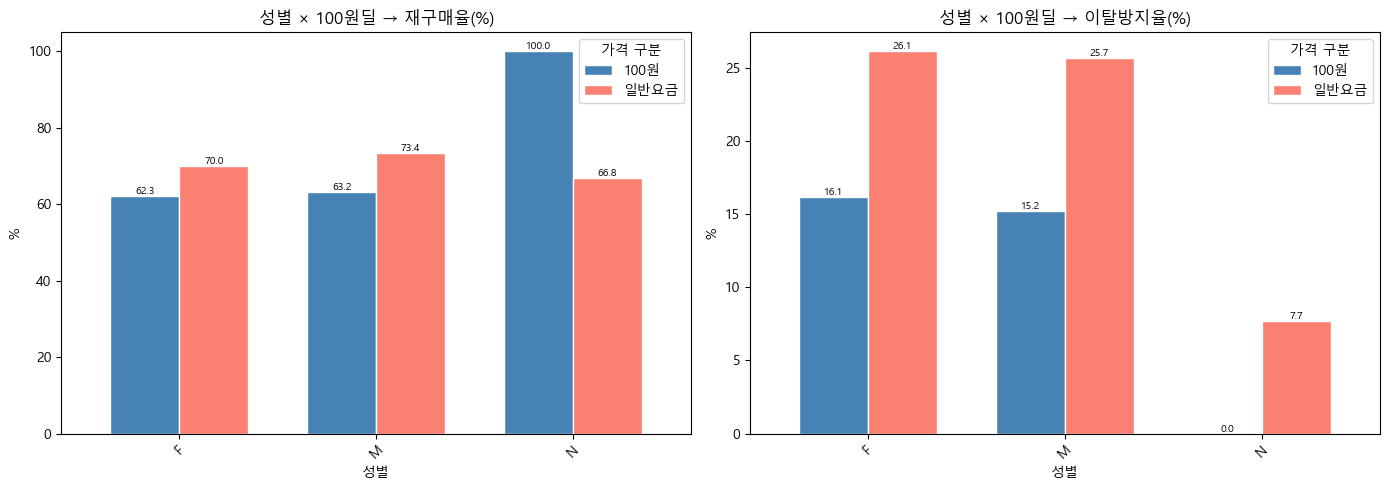

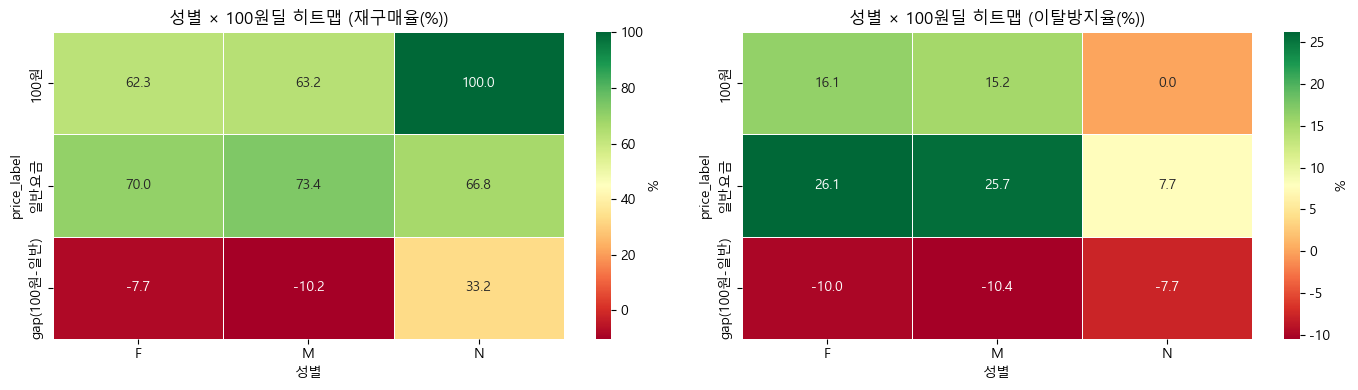

=== 성별 × 가격구분별 재구매율/이탈방지율 (%) ===
                    is_repurchase  is_churn_prevented
gender price_label                                   
F      100원                 62.29               16.15
       일반요금                 70.01               26.13
M      100원                 63.15               15.23
       일반요금                 73.36               25.66
N      100원                100.00                0.00
       일반요금                 66.84                7.66


In [2]:
interaction_barplot(df, 'gender', '성별')
interaction_heatmap(df, 'gender', '성별')

print('=== 성별 × 가격구분별 재구매율/이탈방지율 (%) ===')
print(df.groupby(['gender', 'price_label'])[OUTCOMES].mean().mul(100).round(2))

---
## 2. is_100 × age_group (연령대)

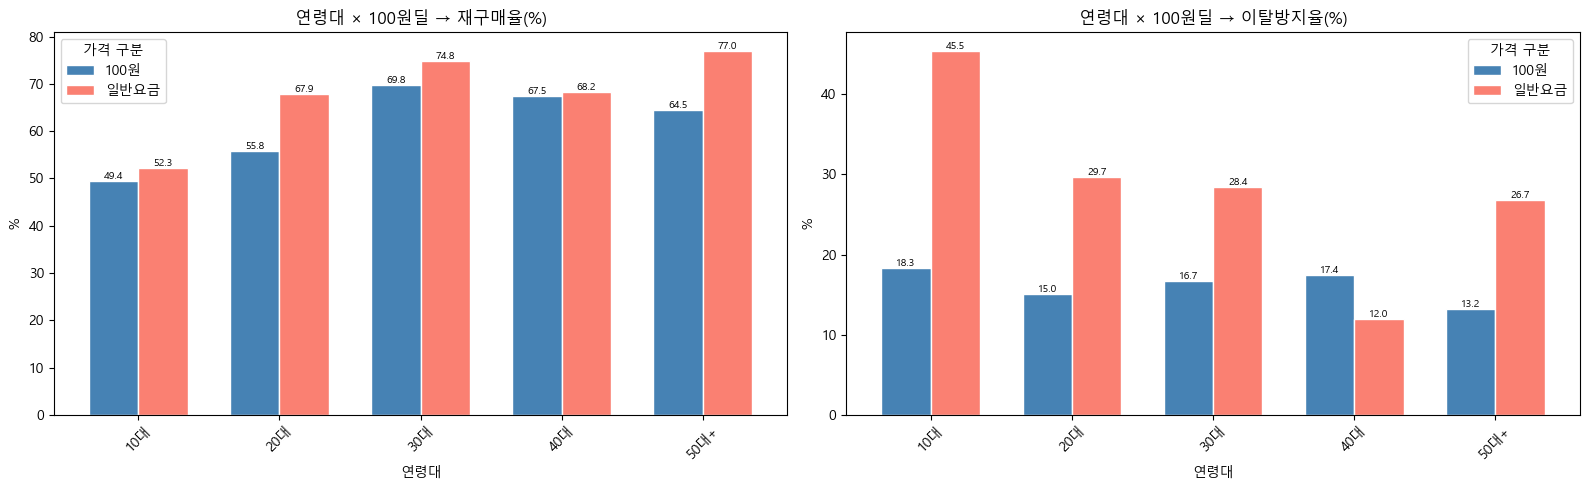

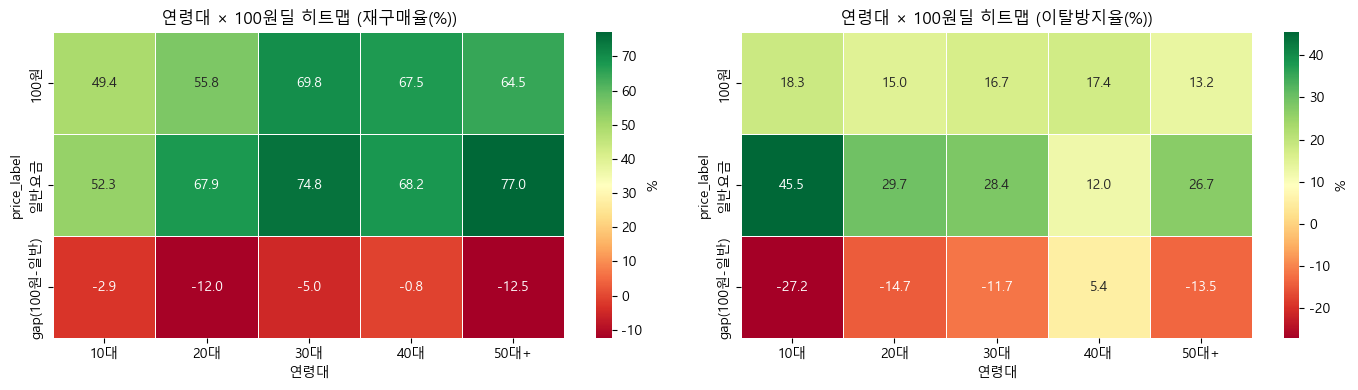

=== 연령대 × 가격구분별 재구매율/이탈방지율 (%) ===
                       is_repurchase  is_churn_prevented
age_group price_label                                   
10대       100원                 49.36               18.30
          일반요금                 52.27               45.45
20대       100원                 55.84               15.05
          일반요금                 67.87               29.70
30대       100원                 69.76               16.69
          일반요금                 74.79               28.43
40대       100원                 67.47               17.44
          일반요금                 68.23               12.01
50대+      100원                 64.54               13.22
          일반요금                 77.05               26.75


In [3]:
interaction_barplot(df, 'age_group', '연령대', figsize=(16, 5))
interaction_heatmap(df, 'age_group', '연령대')

print('=== 연령대 × 가격구분별 재구매율/이탈방지율 (%) ===')
print(df.groupby(['age_group', 'price_label'])[OUTCOMES].mean().mul(100).round(2))

---
## 3. is_100 × payment_device (결제 기기)

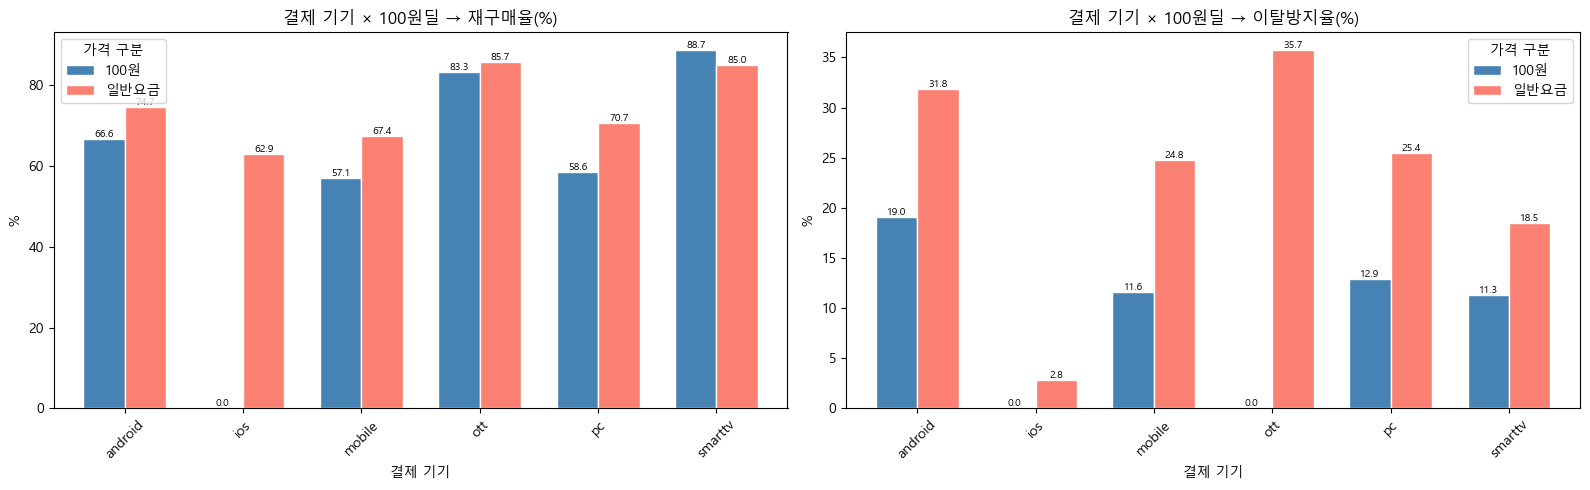

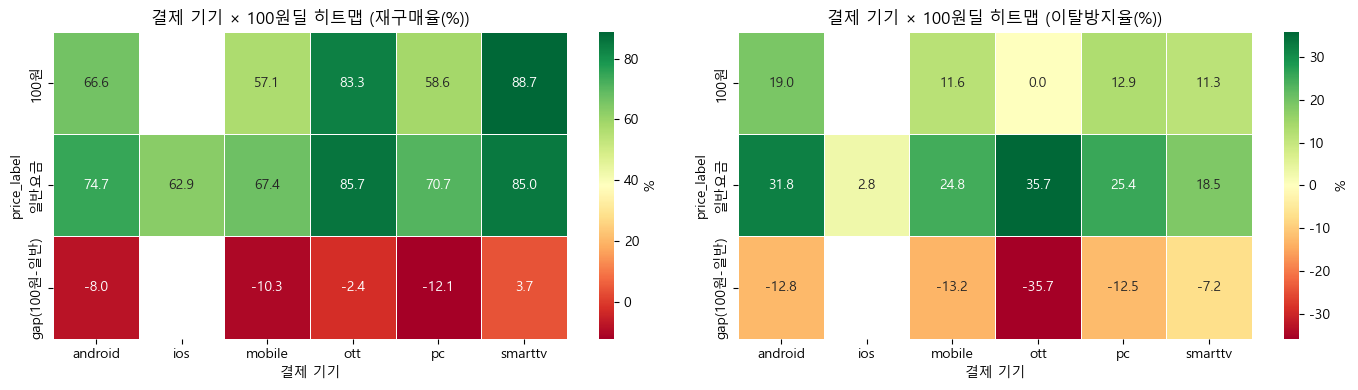

=== 결제기기 × 가격구분별 재구매율/이탈방지율 (%) ===
                            is_repurchase  is_churn_prevented
payment_device price_label                                   
android        100원                 66.61               19.05
               일반요금                 74.65               31.82
ios            일반요금                 62.88                2.80
mobile         100원                 57.10               11.59
               일반요금                 67.41               24.79
ott            100원                 83.33                0.00
               일반요금                 85.71               35.71
pc             100원                 58.61               12.91
               일반요금                 70.69               25.42
smarttv        100원                 88.68               11.32
               일반요금                 85.00               18.50


In [4]:
interaction_barplot(df, 'payment_device', '결제 기기', figsize=(16, 5))
interaction_heatmap(df, 'payment_device', '결제 기기')

print('=== 결제기기 × 가격구분별 재구매율/이탈방지율 (%) ===')
print(df.groupby(['payment_device', 'price_label'])[OUTCOMES].mean().mul(100).round(2))

---
## 4. is_100 × max_screen (동시접속 화면 수)

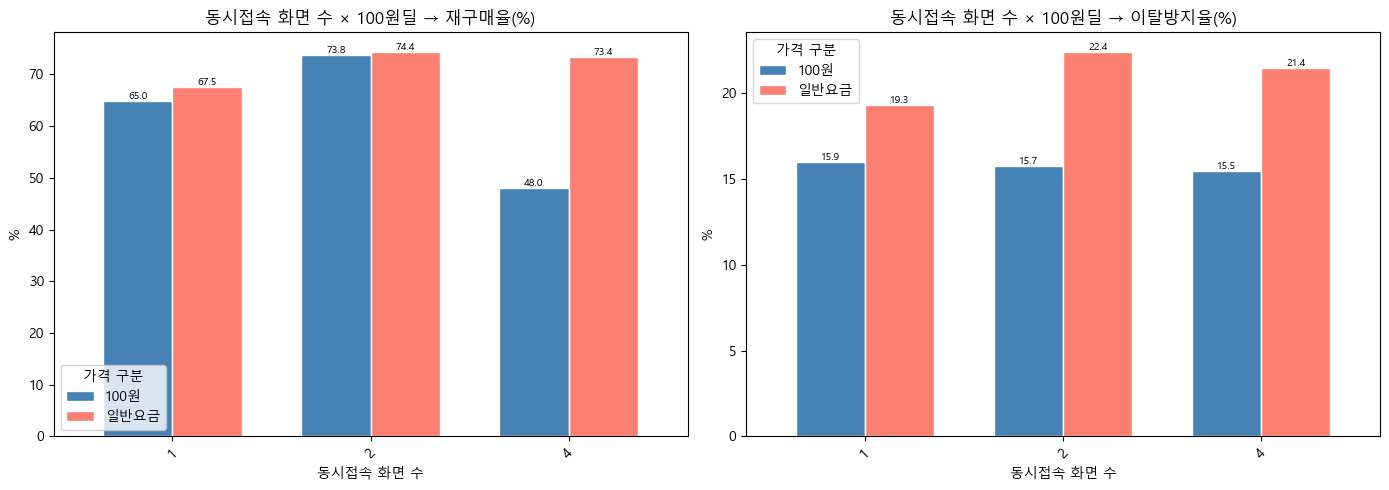

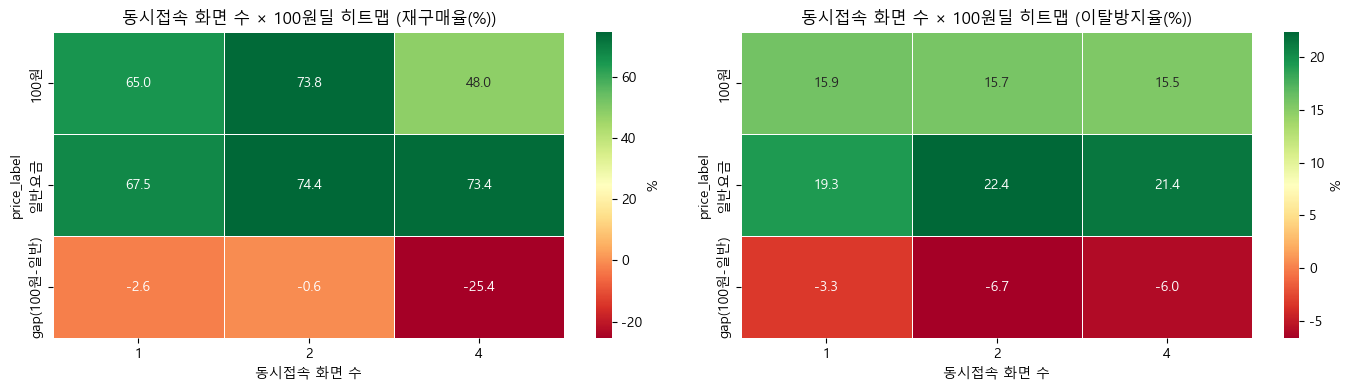

=== max_screen × 가격구분별 재구매율/이탈방지율 (%) ===
                        is_repurchase  is_churn_prevented
max_screen price_label                                   
1          100원                 64.95               15.94
           일반요금                 67.54               19.25
2          100원                 73.83               15.73
           일반요금                 74.43               22.38
4          100원                 48.02               15.45
           일반요금                 73.37               21.42


In [5]:
interaction_barplot(df, 'max_screen', '동시접속 화면 수')
interaction_heatmap(df, 'max_screen', '동시접속 화면 수')

print('=== max_screen × 가격구분별 재구매율/이탈방지율 (%) ===')
print(df.groupby(['max_screen', 'price_label'])[OUTCOMES].mean().mul(100).round(2))

---
## 5. is_100 × billing_method (결제 방식)

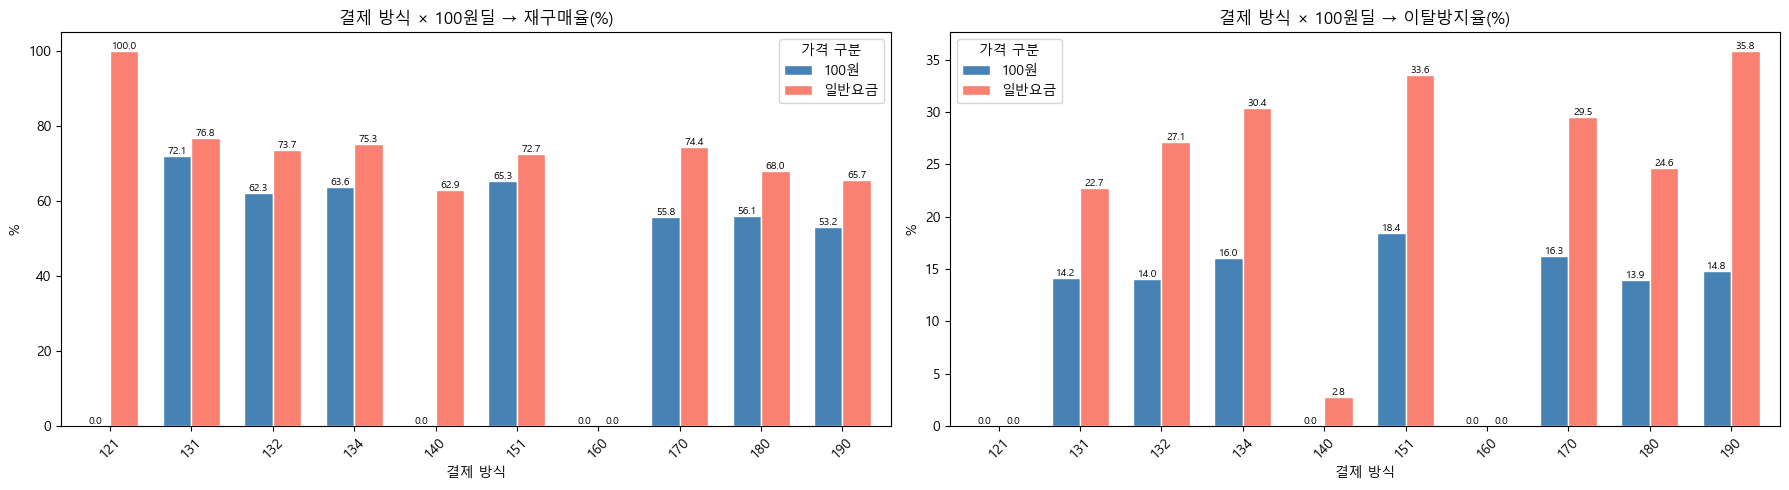

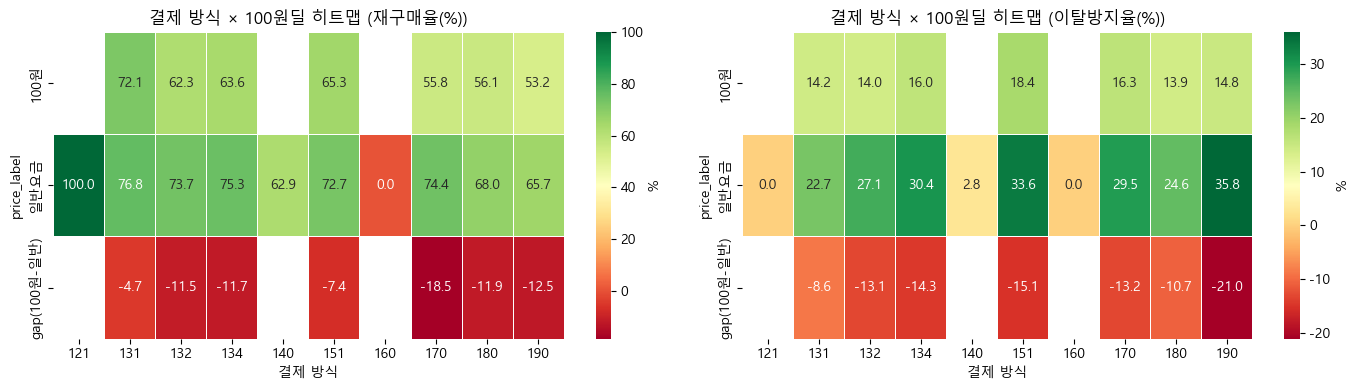

=== billing_method × 가격구분별 재구매율/이탈방지율 (%) ===
                            is_repurchase  is_churn_prevented
billing_method price_label                                   
121            일반요금                100.00                0.00
131            100원                 72.09               14.16
               일반요금                 76.81               22.73
132            100원                 62.27               14.01
               일반요금                 73.74               27.09
134            100원                 63.64               16.02
               일반요금                 75.35               30.36
140            일반요금                 62.88                2.80
151            100원                 65.25               18.42
               일반요금                 72.68               33.56
160            일반요금                  0.00                0.00
170            100원                 55.81               16.28
               일반요금                 74.36               29.49
180            100원     

In [6]:
interaction_barplot(df, 'billing_method', '결제 방식', figsize=(18, 5))
interaction_heatmap(df, 'billing_method', '결제 방식')

print('=== billing_method × 가격구분별 재구매율/이탈방지율 (%) ===')
print(df.groupby(['billing_method', 'price_label'])[OUTCOMES].mean().mul(100).round(2))

---
## 6. is_100 × reg_hour_group (가입 시간대)

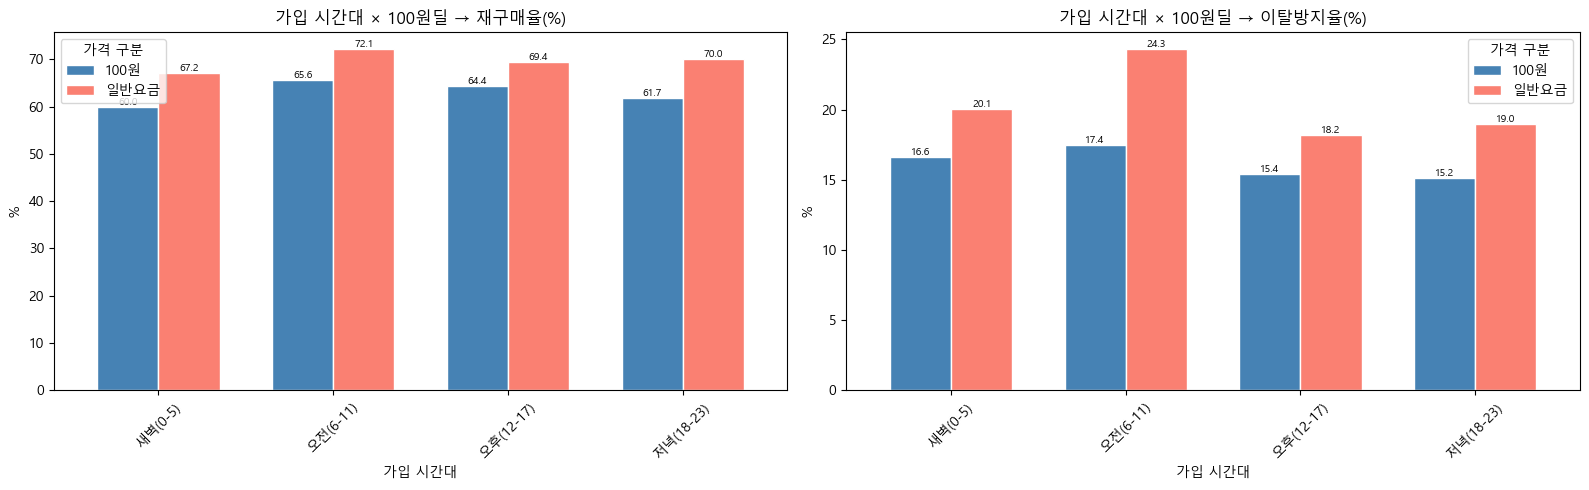

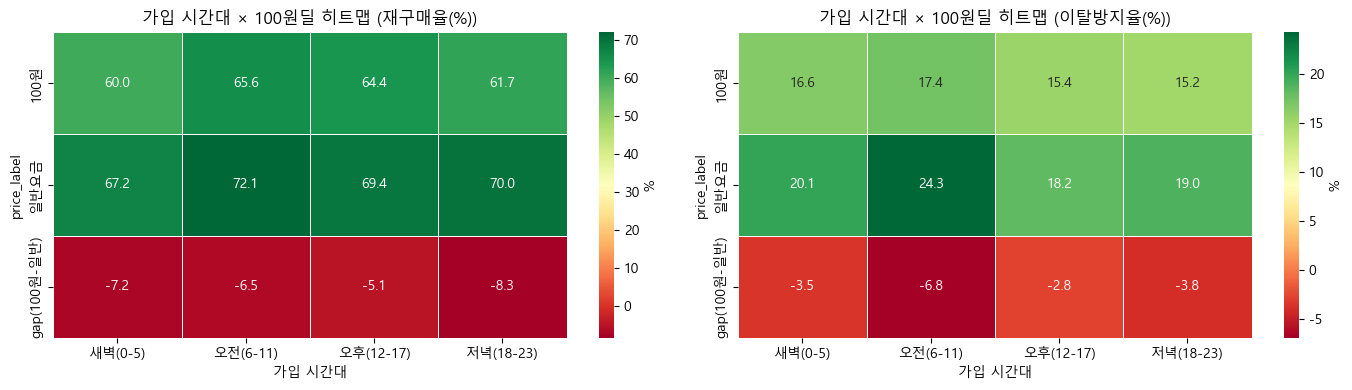

=== 가입시간대 × 가격구분별 재구매율/이탈방지율 (%) ===
                            is_repurchase  is_churn_prevented
reg_hour_group price_label                                   
새벽(0-5)        100원                 59.97               16.59
               일반요금                 67.20               20.06
오전(6-11)       100원                 65.58               17.44
               일반요금                 72.09               24.29
오후(12-17)      100원                 64.37               15.43
               일반요금                 69.43               18.22
저녁(18-23)      100원                 61.72               15.15
               일반요금                 70.00               18.99


In [7]:
interaction_barplot(df, 'reg_hour_group', '가입 시간대', figsize=(16, 5))
interaction_heatmap(df, 'reg_hour_group', '가입 시간대')

print('=== 가입시간대 × 가격구분별 재구매율/이탈방지율 (%) ===')
print(df.groupby(['reg_hour_group', 'price_label'])[OUTCOMES].mean().mul(100).round(2))

---
## 7. is_100 × is_promotion (프로모션 여부)

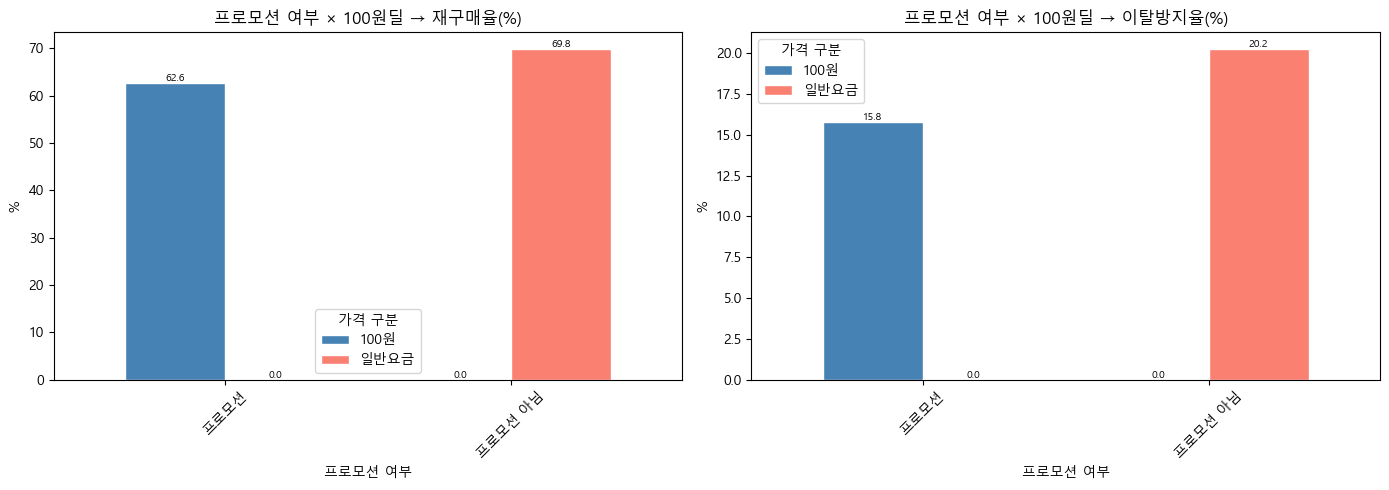

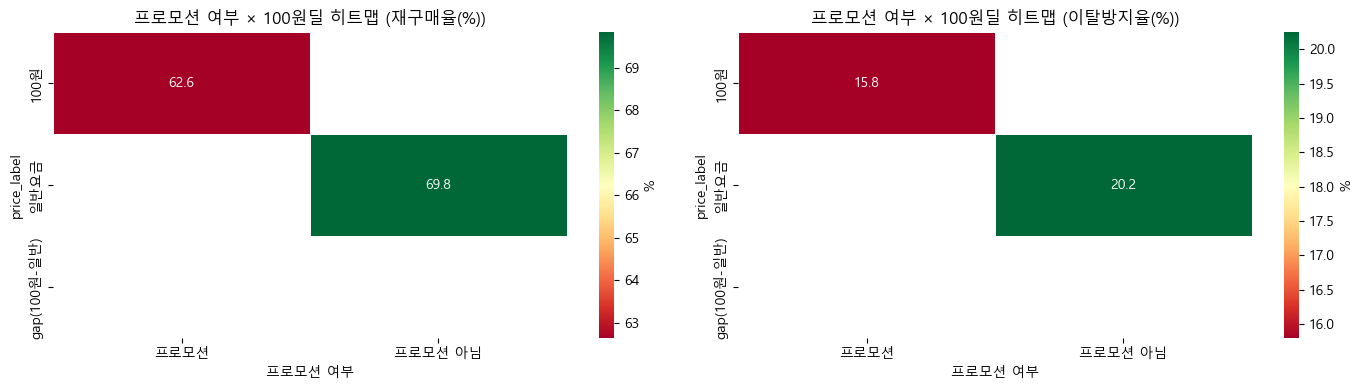

=== 프로모션여부 × 가격구분별 재구매율/이탈방지율 (%) ===
                                is_repurchase  is_churn_prevented
is_promotion_label price_label                                   
프로모션               100원                 62.63               15.79
프로모션 아님            일반요금                 69.84               20.25


In [8]:
df['is_promotion_label'] = df['is_promotion'].map({0: '프로모션 아님', 1: '프로모션'})

interaction_barplot(df, 'is_promotion_label', '프로모션 여부')
interaction_heatmap(df, 'is_promotion_label', '프로모션 여부')

print('=== 프로모션여부 × 가격구분별 재구매율/이탈방지율 (%) ===')
print(df.groupby(['is_promotion_label', 'price_label'])[OUTCOMES].mean().mul(100).round(2))

---
## 8. 교호작용 gap 종합 요약 (100원 - 일반요금 차이)

In [9]:
interaction_vars = [
    ('gender',            '성별'),
    ('age_group',         '연령대'),
    ('payment_device',    '결제기기'),
    ('max_screen',        '동시접속수'),
    ('billing_method',    '결제방식'),
    ('reg_hour_group',    '가입시간대'),
    ('is_promotion_label','프로모션여부'),
]

for outcome in OUTCOMES:
    print(f'\n===== {OUTCOME_LABELS[outcome]} — 100원딜 효과 gap (100원 - 일반요금) =====')
    rows = []
    for col, label in interaction_vars:
        pivot = df.groupby([col, 'price_label'])[outcome].mean().mul(100).unstack('price_label')
        if '100원' in pivot.columns and '일반요금' in pivot.columns:
            pivot['gap'] = pivot['100원'] - pivot['일반요금']
            for idx, row in pivot.iterrows():
                rows.append({'변수': label, '카테고리': str(idx),
                             '100원(%)': round(row.get('100원', np.nan), 2),
                             '일반요금(%)': round(row.get('일반요금', np.nan), 2),
                             'gap(100원-일반)': round(row['gap'], 2)})
    summary = pd.DataFrame(rows).set_index(['변수', '카테고리'])
    print(summary.to_string())


===== 재구매율(%) — 100원딜 효과 gap (100원 - 일반요금) =====
                  100원(%)  일반요금(%)  gap(100원-일반)
변수     카테고리                                     
성별     F            62.29    70.01         -7.71
       M            63.15    73.36        -10.21
       N           100.00    66.84         33.16
연령대    10대          49.36    52.27         -2.91
       20대          55.84    67.87        -12.04
       30대          69.76    74.79         -5.03
       40대          67.47    68.23         -0.75
       50대+         64.54    77.05        -12.50
결제기기   android      66.61    74.65         -8.04
       ios            NaN    62.88           NaN
       mobile       57.10    67.41        -10.31
       ott          83.33    85.71         -2.38
       pc           58.61    70.69        -12.09
       smarttv      88.68    85.00          3.68
동시접속수  1            64.95    67.54         -2.58
       2            73.83    74.43         -0.60
       4            48.02    73.37        -25.35
결제방식   121         

---
## 9. 교호작용 gap 시각화 (버블/스트립 차트)

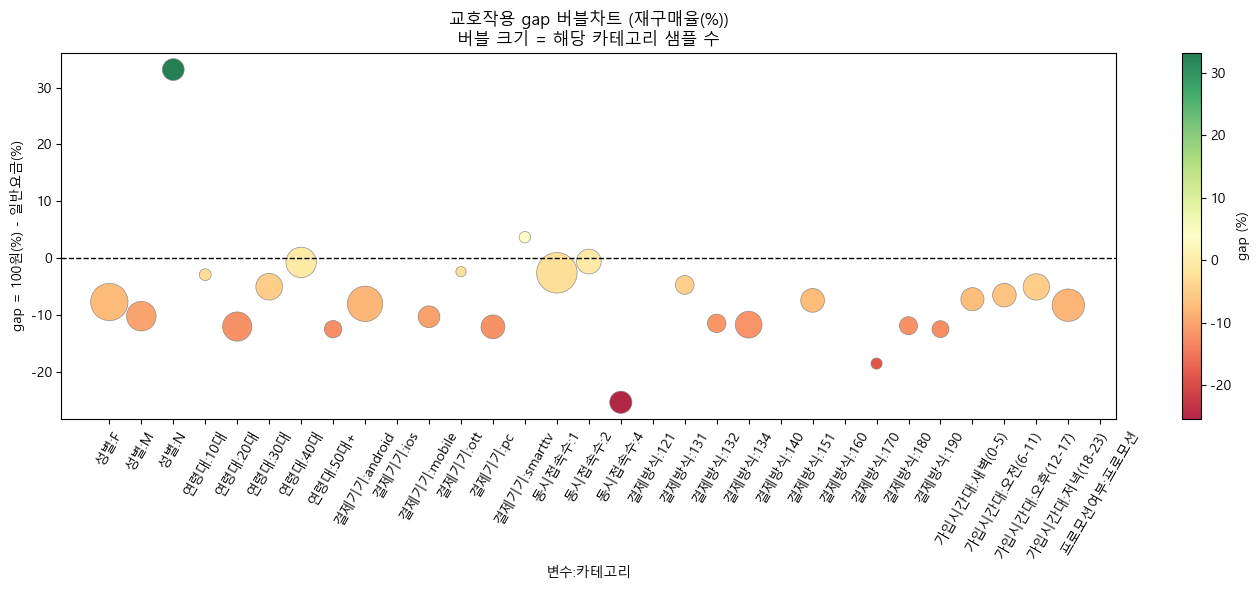

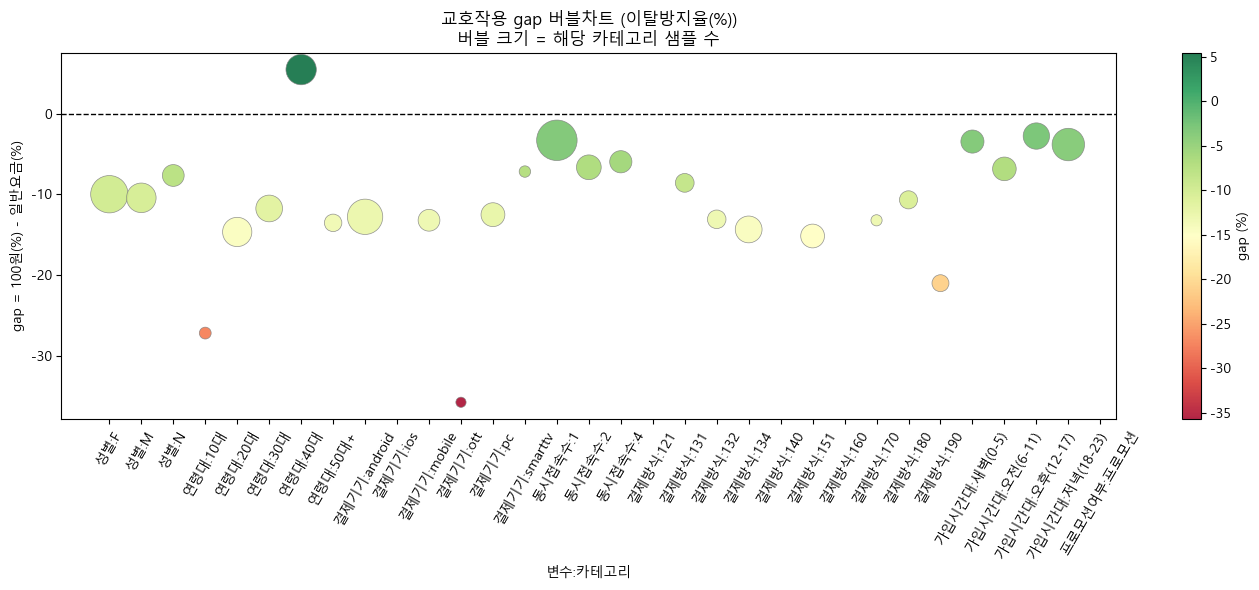

In [10]:
for outcome in OUTCOMES:
    records = []
    for col, label in interaction_vars:
        pivot = df.groupby([col, 'price_label'])[outcome].mean().mul(100).unstack('price_label')
        if '100원' in pivot.columns and '일반요금' in pivot.columns:
            pivot['gap'] = pivot['100원'] - pivot['일반요금']
            cnt = df.groupby(col).size()
            for idx, row in pivot.iterrows():
                records.append({'변수': label, '카테고리': f'{label}:{idx}',
                                'gap': row['gap'], 'n': cnt.get(idx, 0)})
    rdf = pd.DataFrame(records)

    fig, ax = plt.subplots(figsize=(14, 6))
    colors = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(rdf)))
    scatter = ax.scatter(rdf['카테고리'], rdf['gap'],
                         s=rdf['n'] / rdf['n'].max() * 800 + 50,
                         c=rdf['gap'], cmap='RdYlGn', edgecolors='gray', linewidth=0.5, alpha=0.85)
    ax.axhline(0, color='black', linewidth=1, linestyle='--')
    plt.colorbar(scatter, ax=ax, label='gap (%)')
    ax.set_title(f'교호작용 gap 버블차트 ({OUTCOME_LABELS[outcome]})\n버블 크기 = 해당 카테고리 샘플 수')
    ax.set_xlabel('변수:카테고리')
    ax.set_ylabel('gap = 100원(%) - 일반요금(%)')
    ax.tick_params(axis='x', rotation=60)
    plt.tight_layout()
    plt.show()